In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras import layers

# Configure plot aesthetics for EDA
plt.rcParams.update({'font.size': 10, 'axes.labelsize': 12, 'axes.titlesize': 14})

In [2]:
# Base path to the 'Dataset' folder
# Update this to your local path based on your environment
base_dir = r".\Dataset"

train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Define the exact subfolder names to include, mapping them logically
acne_subclasses = ['Acne_Mild', 'Acne_Moderate', 'Acne_Severe']
eczema_subclasses = ['Eczema_Mild', 'Eczema_Moderate', 'Eczema_Severe']

# Combine into a single list. TensorFlow will assign labels 0-2 for Acne, and 3-5 for Eczema.
target_classes = acne_subclasses + eczema_subclasses

BATCH_SIZE = 32
IMG_SIZE = (224, 224) # Standard input size for many CNNs

In [3]:
# Load Train, Validation, and Test sets directly from their respective folders
# Setting class_names ensures 'Normal' and 'Xyz' folders are completely ignored

print("Loading Training Data:")
train_ds = image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=target_classes,
    label_mode='int' 
)

print("\nLoading Validation Data:")
val_ds = image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=target_classes,
    label_mode='int'
)

print("\nLoading Test Data:")
test_ds = image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=target_classes,
    label_mode='int'
)

Loading Training Data:
Found 2723 files belonging to 6 classes.

Loading Validation Data:
Found 582 files belonging to 6 classes.

Loading Test Data:
Found 594 files belonging to 6 classes.


In [4]:
# Current labels: 0, 1, 2 = Acne | 3, 4, 5 = Eczema
# We will map labels >= 3 to 1 (Eczema), and everything else to 0 (Acne)

def map_to_binary(image, label):
    # tf.cast converts boolean (True/False) to integers (1/0)
    binary_label = tf.cast(label >= 3, tf.int32)
    return image, binary_label

# Apply the mapping function to all datasets
train_ds = train_ds.map(map_to_binary, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(map_to_binary, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(map_to_binary, num_parallel_calls=tf.data.AUTOTUNE)

binary_class_names = ['Acne', 'Eczema']
print("Labels successfully remapped to Binary: 0 for Acne, 1 for Eczema")

Labels successfully remapped to Binary: 0 for Acne, 1 for Eczema


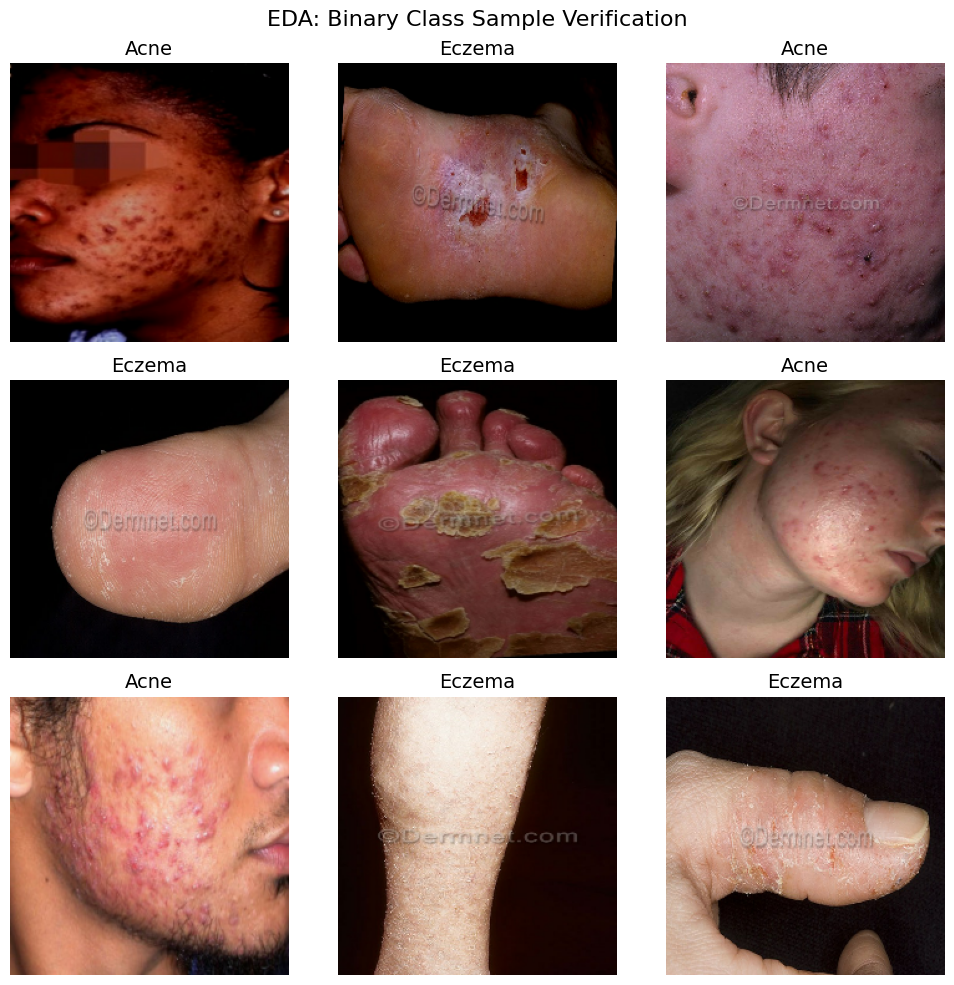

In [5]:
# Extract a batch to visually verify the images and their new binary labels
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # Convert tensor to numpy array for plotting
        plt.imshow(images[i].numpy().astype("uint8"))
        
        # Look up the new binary label
        current_label = int(labels[i].numpy())
        plt.title(binary_class_names[current_label])
        plt.axis("off")
        
plt.suptitle("EDA: Binary Class Sample Verification", fontsize=16)
plt.tight_layout()
plt.show()

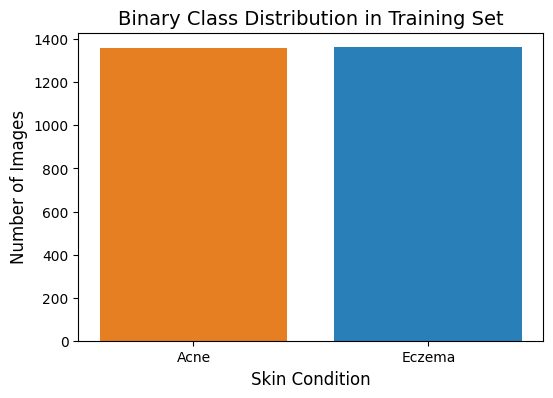

Total Acne Images (Train): 1361
Total Eczema Images (Train): 1362


In [6]:
# Iterate through the training set to check for data imbalance
acne_count = 0
eczema_count = 0

for _, labels in train_ds:
    batch_labels = labels.numpy()
    acne_count += np.sum(batch_labels == 0)
    eczema_count += np.sum(batch_labels == 1)

# Plot the distribution
plt.figure(figsize=(6, 4))
plt.bar(binary_class_names, [acne_count, eczema_count], color=['#e67e22', '#2980b9'])
plt.title("Binary Class Distribution in Training Set")
plt.xlabel("Skin Condition")
plt.ylabel("Number of Images")
plt.show()

print(f"Total Acne Images (Train): {acne_count}")
print(f"Total Eczema Images (Train): {eczema_count}")

In [7]:
# Define augmentation (only applied to the training set)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1)
])

# Create a mapping function that scales pixels and applies augmentation
def preprocess_train(image, label):
    # Rescale pixels to [0, 1] range
    image = tf.cast(image, tf.float32) / 255.0
    # Apply augmentation
    image = data_augmentation(image, training=True)
    return image, label

def preprocess_val_test(image, label):
    # Only rescale pixels for validation and test sets (no augmentation)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

AUTOTUNE = tf.data.AUTOTUNE

# Apply preprocessing and optimize loading performance via caching and prefetching
train_ds = train_ds.map(preprocess_train, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

val_ds = val_ds.map(preprocess_val_test, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

test_ds = test_ds.map(preprocess_val_test, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Preprocessing complete. Datasets are optimized and ready for model training.")

Preprocessing complete. Datasets are optimized and ready for model training.


In [8]:
# Import the specific pre-trained model from Keras applications
from tensorflow.keras.applications import MobileNetV2

# Define the input shape established during preprocessing (224x224 RGB images)
IMG_SHAPE = IMG_SIZE + (3,)

# Load the base model with pre-trained ImageNet weights
# include_top=False excludes the original 1000-class classification network
base_model = MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)

# Freeze the convolutional base to preserve the established 'knowledge'
# This prevents the weights from being updated during the initial training phase
base_model.trainable = False

print("Pre-trained MobileNetV2 base loaded and frozen.")
base_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Pre-trained MobileNetV2 base loaded and frozen.


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
# Build the final model architecture using the Functional API
inputs = tf.keras.Input(shape=IMG_SHAPE)

# Pass the inputs through the frozen base model
# training=False is crucial here; it ensures layers like BatchNormalization run in inference mode
x = base_model(inputs, training=False)

# Convert the spatial features from the base model into a single 1D vector per image
x = layers.GlobalAveragePooling2D()(x)

# Add a Dropout layer for regularization to prevent overfitting on the new classification head
x = layers.Dropout(0.2)(x)

# Final Output Layer:
# 1 single neuron because we are predicting a single probability (Acne vs Eczema)
# 'sigmoid' activation squashes the output to a strict range between 0.0 and 1.0
outputs = layers.Dense(1, activation='sigmoid')(x)

# Construct the final cohesive model
model = tf.keras.Model(inputs, outputs, name="Acne_vs_Eczema_Classifier")

print("Custom classification head successfully built on top of the base model.")

Custom classification head successfully built on top of the base model.


In [10]:
# Define the learning rate for the optimizer
# A standard starting point like 1e-3 is generally effective for a frozen base
base_learning_rate = 0.001

# Compile the model explicitly for our mapped binary setup
model.compile(
    # Adam is a robust, adaptive optimizer suitable for most image classification tasks
    optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
    
    # BinaryCrossentropy is mandatory since our labels are strictly 0 or 1
    loss=tf.keras.losses.BinaryCrossentropy(),
    
    # Track standard accuracy during training and validation
    metrics=['accuracy']
)

# Display the complete architecture and verify the trainable vs non-trainable parameters
model.summary()

Model: "Acne_vs_Eczema_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=5,               # Stop after 5 epochs with no improvement
    restore_best_weights=True, 
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2,               # Reduce learning rate by 20%
    patience=3,               # Wait 3 epochs before reducing
    min_lr=1e-6,              # Lower bound for learning rate
    verbose=1
)

# Train the custom head
EPOCHS = 20

print("Starting initial training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr]
)

Starting initial training...
Epoch 1/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 105s 792ms/step - accuracy: 0.7771 - loss: 0.4542 - val_accuracy: 0.8522 - val_loss: 0.3383 - learning_rate: 0.0010
Epoch 2/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 64s 743ms/step - accuracy: 0.8744 - loss: 0.3031 - val_accuracy: 0.8935 - val_loss: 0.2811 - learning_rate: 0.0010
Epoch 3/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 62s 724ms/step - accuracy: 0.8898 - loss: 0.2733 - val_accuracy: 0.9021 - val_loss: 0.2576 - learning_rate: 0.0010
Epoch 4/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 62s 719ms/step - accuracy: 0.8964 - loss: 0.2540 - val_accuracy: 0.8918 - val_loss: 0.2604 - learning_rate: 0.0010
Epoch 5/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 62s 723ms/step - accuracy: 0.8986 - loss: 0.2405 - val_accuracy: 0.8986 - val_loss: 0.2464 - learning_rate: 0.0010
Epoch 6/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 60s 701ms/step - accuracy: 0.9097 - loss: 0.2266 - val_accuracy: 0.9021 - val_loss: 0.2376 - learning_rate: 0.0010
Epoch 7/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 61s 713ms/step

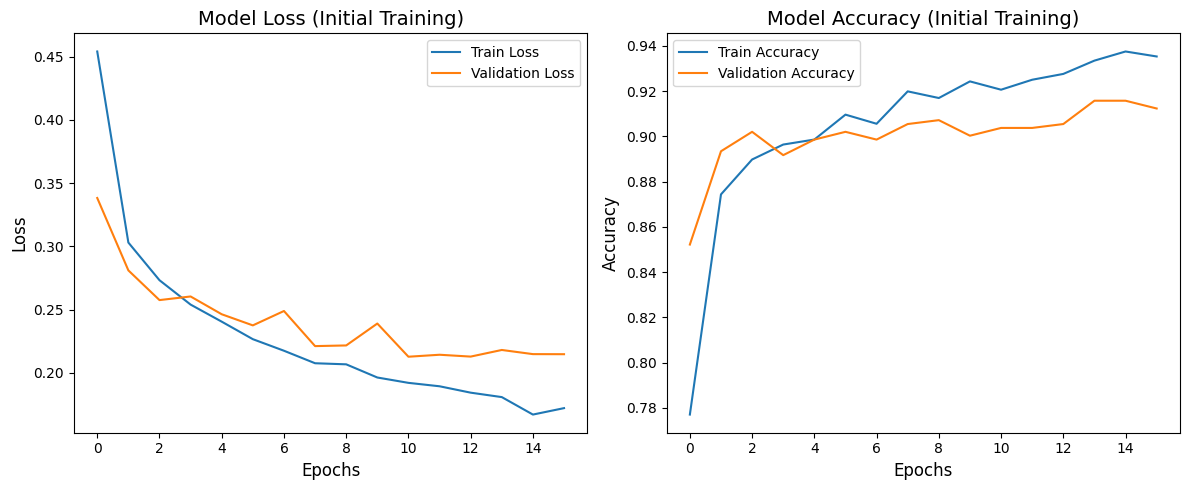

In [12]:
import matplotlib.pyplot as plt

def plot_history(history, title_suffix=""):
    # Create a figure with two subplots
    plt.figure(figsize=(12, 5))
    
    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Model Loss {title_suffix}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Model Accuracy {title_suffix}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Visualize the initial training run
plot_history(history, title_suffix="(Initial Training)")

In [13]:
# Evaluate the model
print("Evaluating on test dataset...")
test_loss, test_acc = model.evaluate(test_ds, verbose=1)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Evaluating on test dataset...
19/19 ━━━━━━━━━━━━━━━━━━━━ 14s 637ms/step - accuracy: 0.9242 - loss: 0.1947

Test Loss: 0.1947
Test Accuracy: 0.9242


Generating predictions for deep dive analysis...


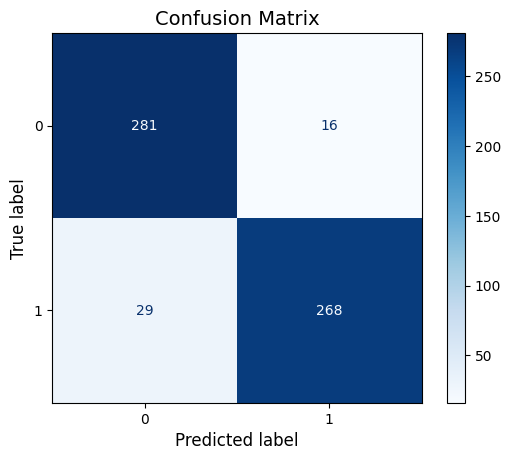


Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       297
           1       0.94      0.90      0.92       297

    accuracy                           0.92       594
   macro avg       0.93      0.92      0.92       594
weighted avg       0.93      0.92      0.92       594



In [14]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Extract true labels and predictions directly from the test_ds
y_true = []
y_pred_probs = []

print("Generating predictions for deep dive analysis...")
for images, labels in test_ds:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

# Convert probabilities to class predictions
# (Use np.argmax for multi-class, or a 0.5 threshold for binary)
if y_pred_probs.shape[-1] > 1:
    y_pred = np.argmax(y_pred_probs, axis=1)
else:
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Ensure true labels are 1D (if they were one-hot encoded, convert them)
if len(y_true.shape) > 1 and y_true.shape[-1] > 1:
    y_true = np.argmax(y_true, axis=1)

# 1. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# 2. Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

Base layers unfrozen. Recompiling model...
Starting fine-tuning...
Epoch 16/26
86/86 ━━━━━━━━━━━━━━━━━━━━ 492s 5s/step - accuracy: 0.8120 - loss: 0.4204 - val_accuracy: 0.8643 - val_loss: 0.3692 - learning_rate: 1.0000e-05
Epoch 17/26
86/86 ━━━━━━━━━━━━━━━━━━━━ 377s 4s/step - accuracy: 0.9041 - loss: 0.2385 - val_accuracy: 0.8505 - val_loss: 0.4274 - learning_rate: 1.0000e-05
Epoch 18/26
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9376 - loss: 0.1743
Epoch 18: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
86/86 ━━━━━━━━━━━━━━━━━━━━ 409s 5s/step - accuracy: 0.9376 - loss: 0.1683 - val_accuracy: 0.8454 - val_loss: 0.4408 - learning_rate: 1.0000e-05
Epoch 19/26
86/86 ━━━━━━━━━━━━━━━━━━━━ 410s 5s/step - accuracy: 0.9622 - loss: 0.1243 - val_accuracy: 0.8557 - val_loss: 0.4126 - learning_rate: 2.0000e-06
Epoch 20/26
86/86 ━━━━━━━━━━━━━━━━━━━━ 390s 5s/step - accuracy: 0.9688 - loss: 0.1108 - val_accuracy: 0.8625 - val_loss: 0.3868 - learning_rate: 2.0000e-06
Epo

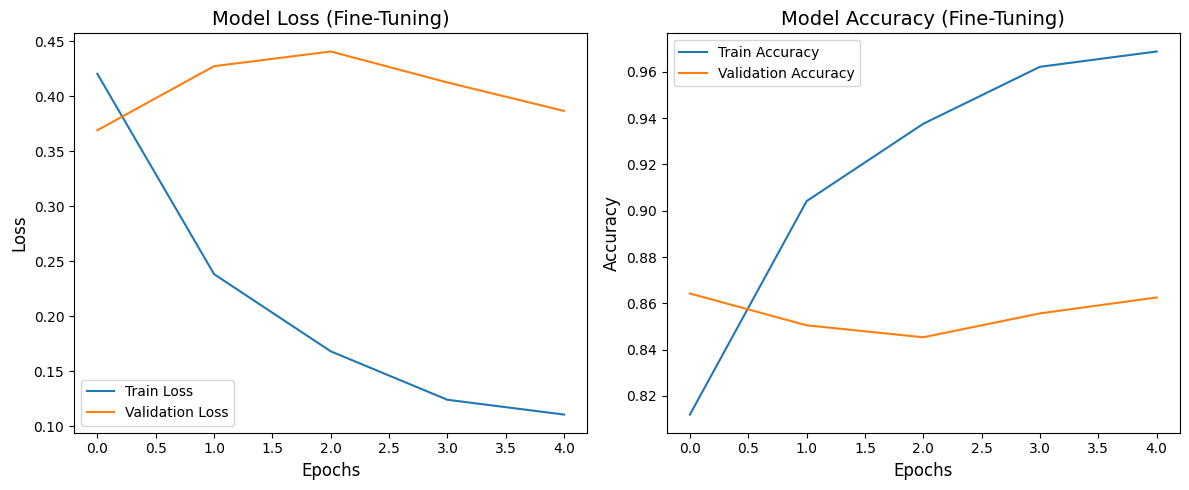


Final Evaluation after Fine-Tuning...
19/19 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.8687 - loss: 0.3645
Final Test Accuracy: 0.8687


In [15]:
# Unfreeze the base model layers
base_model.trainable = True
print("Base layers unfrozen. Recompiling model...")

# Recompile the model with a much smaller learning rate (e.g., 1e-5)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=model.loss,       # Reuse the same loss function
    metrics=['accuracy']   # Reuse the same metrics
)

# Train for a few more epochs
FINE_TUNE_EPOCHS = 10
TOTAL_EPOCHS = history.epoch[-1] + 1 + FINE_TUNE_EPOCHS

print("Starting fine-tuning...")
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=TOTAL_EPOCHS,
    initial_epoch=history.epoch[-1], # Resume training from the exact epoch we left off
    callbacks=[early_stopping, reduce_lr]
)

# Visualize the fine-tuning history
plot_history(history_fine, title_suffix="(Fine-Tuning)")

# Final Evaluation
print("\nFinal Evaluation after Fine-Tuning...")
final_test_loss, final_test_acc = model.evaluate(test_ds, verbose=1)
print(f"Final Test Accuracy: {final_test_acc:.4f}")

In [16]:
import os

# Define the filename and path where you want to save the model
# Ensure the file ends with '.keras'
model_filename = 'best_model.keras'
save_path = os.path.join(base_dir, model_filename)

print(f"Saving the finalized model to {save_path}...")

# Save the model
model.save(save_path)

print(f"Model successfully saved! You can now load this model for inference or deployment.")

Saving the finalized model to .\Dataset\best_model.keras...
Model successfully saved! You can now load this model for inference or deployment.
